<a href="https://colab.research.google.com/github/one-2730/ESSA-25-1/blob/Session/ESAA_OB_0516_Session2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. PyTorch Workflow Exercise Template

The following is a template for the PyTorch workflow exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [2]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Setup device-agnostic code


## 1. Create a straight line dataset using the linear regression formula (`weight * X + bias`).
  * Set `weight=0.3` and `bias=0.9` there should be at least 100 datapoints total.
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

Your output of the below cell should look something like:
```
Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])
```

Of course the numbers in `X` and `y` may be different but ideally they're created using the linear regression formula.

In [12]:
# Create the data parameters
weight=0.3
bias=0.9
num_points=101

# Make X and y using linear regression feature
X = torch.linspace(0, 1, num_points).unsqueeze(1)
y = weight * X + bias

print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}")

Number of X samples: 101
Number of y samples: 101
First 10 X & y samples:
X: tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])
y: tensor([[0.9000],
        [0.9030],
        [0.9060],
        [0.9090],
        [0.9120],
        [0.9150],
        [0.9180],
        [0.9210],
        [0.9240],
        [0.9270]])


In [13]:
# Split the data into training and testing
train_split = int(len(X) * 0.8)
X_train = X[:train_split]
y_train = y[:train_split]
X_test = X[train_split:]
y_test = y[train_split:]

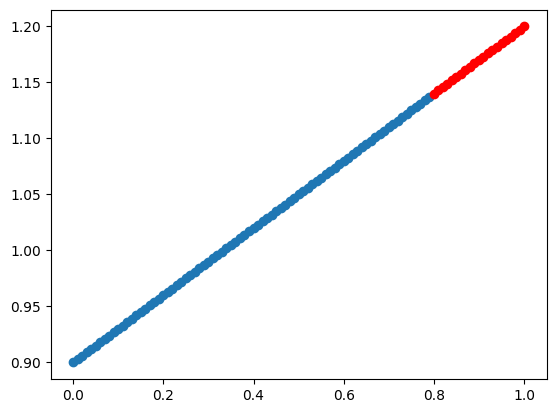

In [14]:
# Plot the training and testing data

plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test, color='red')
plt.show()

## 2. Build a PyTorch model by subclassing `nn.Module`.
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`.
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in 1.
  * Once you've constructed the model, make an instance of it and check its `state_dict()`.
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can.

In [15]:
# Create PyTorch linear regression model by subclassing nn.Module

class LinearReg(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(1, 1)

  def forward(self, x):
    return self.linear(x)

In [16]:
# Instantiate the model and put it to the target device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = LinearReg()
model.to(device)

LinearReg(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

## 3. Create a loss function and optimizer using `nn.L1Loss()` and `torch.optim.SGD(params, lr)` respectively.
  * Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
  * Write a training loop to perform the appropriate training steps for 300 epochs.
  * The training loop should test the model on the test dataset every 20 epochs.

In [22]:
# Create the loss function and optimizer
criterion = nn.L1Loss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [23]:
# Train model for 300 epochs
num_epochs = 300

# Send data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(num_epochs):
  ### Training
  model.train()  # Put model in train mode

  # 1. Forward pass
  y_pred = model(X_train)

  # 2. Calculate loss
  loss = criterion(y_pred, y_train)

  # 3. Zero gradients
  optimizer.zero_grad()

  # 4. Backpropagation
  loss.backward()

  # 5. Step the optimizer
  optimizer.step()

  ### Perform testing every 20 epochs
  if epoch % 20 == 0:
    model.eval()  # Put model in eval mode
    with torch.no_grad():  # Inference mode
      # 1. Forward pass
      test_pred = model(X_test)

      # 2. Calculate test loss
      test_loss = criterion(test_pred, y_test)

    # Print out what's happening
    print(f"Epoch: {epoch:03d} | Train loss: {loss:.4f} | Test loss: {test_loss:.4f}")

Epoch: 000 | Train loss: 0.5892 | Test loss: 1.0830
Epoch: 020 | Train loss: 0.3581 | Test loss: 0.8122
Epoch: 040 | Train loss: 0.2169 | Test loss: 0.5994
Epoch: 060 | Train loss: 0.1666 | Test loss: 0.4689
Epoch: 080 | Train loss: 0.1479 | Test loss: 0.3928
Epoch: 100 | Train loss: 0.1382 | Test loss: 0.3473
Epoch: 120 | Train loss: 0.1308 | Test loss: 0.3182
Epoch: 140 | Train loss: 0.1238 | Test loss: 0.2958
Epoch: 160 | Train loss: 0.1170 | Test loss: 0.2786
Epoch: 180 | Train loss: 0.1101 | Test loss: 0.2625
Epoch: 200 | Train loss: 0.1033 | Test loss: 0.2460
Epoch: 220 | Train loss: 0.0964 | Test loss: 0.2295
Epoch: 240 | Train loss: 0.0896 | Test loss: 0.2133
Epoch: 260 | Train loss: 0.0827 | Test loss: 0.1968
Epoch: 280 | Train loss: 0.0759 | Test loss: 0.1803


## 4. Make predictions with the trained model on the test data.
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

In [29]:
# Make predictions with the model
model.eval()

with torch.inference_mode():
  y_preds = model(X_test)
print(y_preds)

print(y_preds.cpu())

tensor([[1.0095],
        [1.0090],
        [1.0086],
        [1.0081],
        [1.0077],
        [1.0073],
        [1.0068],
        [1.0064],
        [1.0060],
        [1.0055],
        [1.0051],
        [1.0046],
        [1.0042],
        [1.0038],
        [1.0033],
        [1.0029],
        [1.0024],
        [1.0020],
        [1.0016],
        [1.0011],
        [1.0007]])
tensor([[1.0095],
        [1.0090],
        [1.0086],
        [1.0081],
        [1.0077],
        [1.0073],
        [1.0068],
        [1.0064],
        [1.0060],
        [1.0055],
        [1.0051],
        [1.0046],
        [1.0042],
        [1.0038],
        [1.0033],
        [1.0029],
        [1.0024],
        [1.0020],
        [1.0016],
        [1.0011],
        [1.0007]])


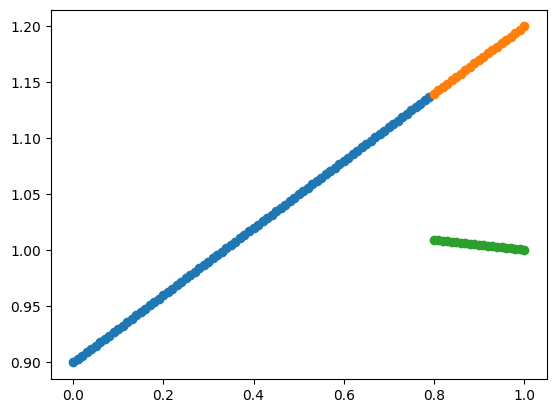

In [31]:
# Plot the predictions (these may need to be on a specific device)
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)
plt.scatter(X_test, y_preds)
plt.show()

## 5. Save your trained model's `state_dict()` to file.
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [32]:
from pathlib import Path

# 1. Create models directory
model_path = Path('models')
model_path.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
model_name = 'pytorch_model'
model_save_path = model_path/model_name

# 3. Save the model state dict
print(f'Saving model to {model_save_path}')
torch.save(obj=model.state_dict(), f=model_save_path)

Saving model to models/pytorch_model


In [34]:
# Create new instance of model and load saved state dict (make sure to put it on the target device)
load_model = LinearReg()
load_model.load_state_dict(torch.load(f=model_save_path))
load_model

LinearReg(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [36]:
# Make predictions with loaded model and compare them to the previous
y_preds_new = load_model(X_test)
print(y_preds==y_preds_new)

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])
